Generate the dataset (uses `src/sample_data.py`)

**Edit `PROJECT_DIR`.**

In [1]:
%pip install tensorflow scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ============================================================
# !important! make the `sample_data.py` file into folder `nsf-fmrg-data-challenge/src` of the original github repo.
# Then, put the direction of `nsf-fmrg-data-challenge` folder on your device below :)
# PROJECT_DIR = Path('/Users/jian/MyProjects/NSF-Future-challenge/nsf-fmrg-data-challenge')

PROJECT_DIR = Path.cwd().parent

print('PROJECT_DIR =', PROJECT_DIR)
# ============================================================

PROJECT_DIR = /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge


In [4]:
sys.path.append(str(PROJECT_DIR / 'src'))
from sample_data import SampleGenerator, TRACK_IDS

In [5]:
gen = SampleGenerator(PROJECT_DIR)
print('tracks:', TRACK_IDS, '| grid:', gen.frame_grid()[[0, 1, -1]], 'mm (400 frame centres)')

tracks: (8, 10, 14, 21) | grid: [20.1 20.3 99.9] mm (400 frame centres)


In [6]:
# one sample on demand (given a track and an x)
s = gen.make_sample(8, 60.1)
print({k: (v.shape if hasattr(v, 'shape') else v) for k, v in s.items()})

{'track_id': 8, 'x': 60.1, 'thermal': (5, 400, 400), 'width_mm': 1.2025640000000002, 'quality': True}


## Width labels over the whole grid

`build_labels()` sweeps every frame-centre x for all tracks and returns `width_mm` + a `quality`
flag (False where x is outside a track's height coverage or an edge is clipped). 

In [7]:
labels = gen.build_labels()            # ~20 s: loads each track's raw height once
out = PROJECT_DIR / 'processed_data' / 'labels_minimal.npz'
np.savez(out, **labels)

n = labels['track_id'].size
print(f'{n} labels  ->  {out.name}')
for t in TRACK_IDS:
    m = labels['track_id'] == t
    q = labels['quality'][m]
    w = labels['width_mm'][m][q] * 1000
    print(f'  track {t:2d}: {m.sum()} rows, quality {q.mean():.0%}, '
          f'median width {np.median(w):.0f} um')

1592 labels  ->  labels_minimal.npz
  track  8: 398 rows, quality 97%, median width 1043 um
  track 10: 398 rows, quality 93%, median width 872 um
  track 14: 398 rows, quality 95%, median width 727 um
  track 21: 398 rows, quality 91%, median width 496 um


In [8]:
## Visualization of width

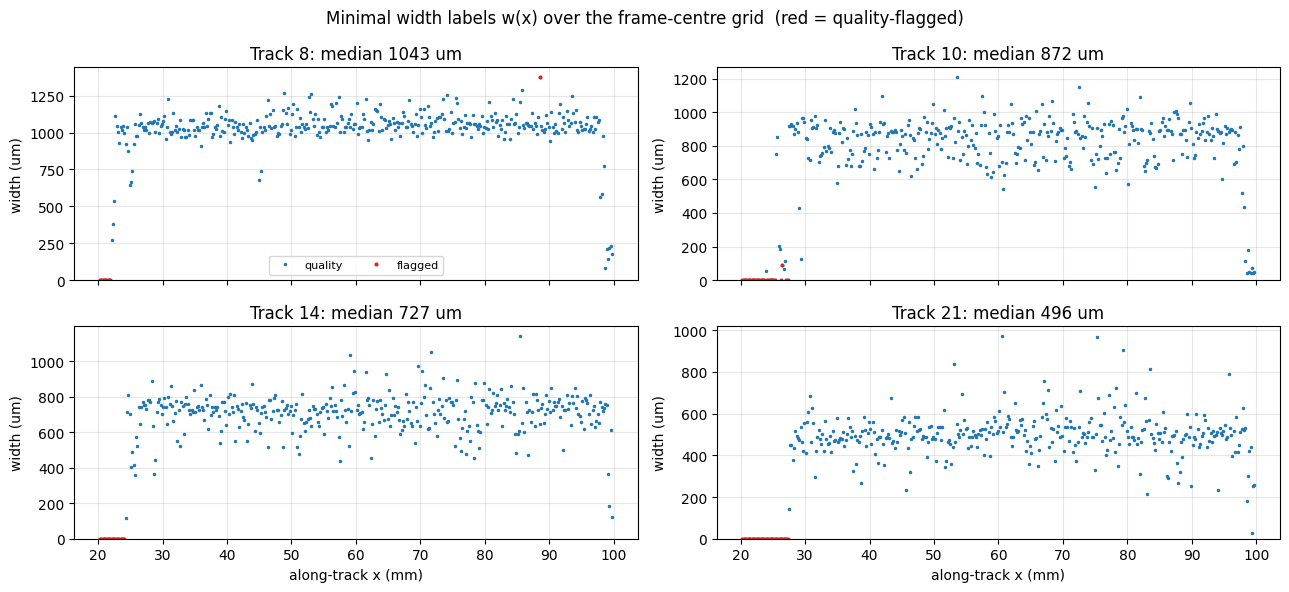

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for ax, t in zip(axes.ravel(), TRACK_IDS):
    m = labels['track_id'] == t
    x, w, q = labels['x_mm'][m], labels['width_mm'][m] * 1000, labels['quality'][m]
    ax.plot(x[q], w[q], '.', ms=3, color='tab:blue', label='quality')
    ax.plot(x[~q], w[~q], '.', ms=4, color='tab:red', label='flagged')
    ax.set_title(f'Track {t}: median {np.median(w[q]):.0f} um'); ax.set_ylim(0, None); ax.grid(alpha=0.3)
    ax.set_ylabel('width (um)')
for ax in axes[1]:
    ax.set_xlabel('along-track x (mm)')
axes[0, 0].legend(loc='lower center', fontsize=8, ncol=2)
fig.suptitle('Minimal width labels w(x) over the frame-centre grid  (red = quality-flagged)')
fig.tight_layout(); plt.show()

In [10]:
# Step 1: load SEM samples and width labels aligned by sample_id
sem_dir = PROJECT_DIR / "Samples" / "SEM Samples"
sem_track = 8
sem_path = sem_dir / f"SEM_samples_Track_{sem_track:02d}.npz"
sem_data = np.load(sem_path, allow_pickle=True)
print("Loaded SEM file:", sem_path)
print("SEM keys:", list(sem_data.keys()))
print("SEM sample count:", sem_data["sample_ids"].shape[0])
print("deposit_only_slices shape:", sem_data["deposit_only_slices"].shape)

label_path = PROJECT_DIR / "processed_data" / "labels_minimal.npz"
labels = np.load(label_path, allow_pickle=True)
print("Loaded label file:", label_path)
print("Label keys:", list(labels.keys()))
print("Label count:", labels["track_id"].shape[0])

# Build canonical sample_id strings from labels to join with SEM sample_ids
label_sample_ids = np.array([
    f"T{int(track):02d}_X{float(x):05.1f}"
    for track, x in zip(labels["track_id"], labels["x_mm"])
])
label_width_mm = labels["width_mm"] * 1000  # convert mm to um if needed
label_quality = labels["quality"]

# Select the current SEM track and good quality labels
track_mask = (labels["track_id"] == sem_track) & label_quality
track_label_ids = label_sample_ids[track_mask]
track_widths = label_width_mm[track_mask]
print(f"Track {sem_track} quality labels: {track_label_ids.size}")

# Find the intersection of SEM samples and label sample_ids
aligned_ids = np.intersect1d(sem_data["sample_ids"], track_label_ids)
print(f"Aligned samples for track {sem_track}: {aligned_ids.size}")

sem_index = {sid: idx for idx, sid in enumerate(sem_data["sample_ids"])}
label_index = {sid: idx for idx, sid in enumerate(label_sample_ids)}
if aligned_ids.size > 0:
    sid = aligned_ids[0]
    print("Example aligned sample_id:", sid)
    print("  SEM x_mm:", sem_data["x_mm"][sem_index[sid]])
    print("  width_mm:", label_width_mm[label_index[sid]])


Loaded SEM file: /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/Samples/SEM Samples/SEM_samples_Track_08.npz
SEM keys: ['sample_ids', 'track_ids', 'x_mm', 'delta_mm', 'interval_bounds_mm', 'raw_slices', 'deposit_only_slices', 'substrate_only_slices', 'deposit_masks', 'interface_safety_bands', 'track_exclusion_masks', 'substrate_masks', 'center_tile_numbers', 'source_tile_numbers', 'crosses_tile_boundary', 'c100_px', 'c20_px', 'physical_to_sem_scale']
SEM sample count: 400
deposit_only_slices shape: (400, 768, 34)
Loaded label file: /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/processed_data/labels_minimal.npz
Label keys: ['track_id', 'x_mm', 'width_mm', 'quality']
Label count: 1592
Track 8 quality labels: 388
Aligned samples for track 8: 388
Example aligned sample_id: T08_X022.1
  SEM x_mm: 22.1
  width_mm: 274.758


In [11]:
# Build the aligned SEM sample dataset for the selected track
aligned_ids = np.intersect1d(sem_data["sample_ids"], track_label_ids)
aligned_ids.sort()

sem_index = {sid: idx for idx, sid in enumerate(sem_data["sample_ids"])}
label_index = {sid: idx for idx, sid in enumerate(label_sample_ids)}
aligned_sem_indices = np.array([sem_index[sid] for sid in aligned_ids], dtype=int)
aligned_label_indices = np.array([label_index[sid] for sid in aligned_ids], dtype=int)

aligned_sem_images = sem_data["deposit_only_slices"][aligned_sem_indices]
aligned_sem_masks = sem_data["deposit_masks"][aligned_sem_indices]
aligned_x_mm = sem_data["x_mm"][aligned_sem_indices]
aligned_width_um = label_width_mm[aligned_label_indices]
aligned_sample_ids = aligned_ids

print("Aligned sample count:", aligned_sample_ids.size)
print("SEM image shape:", aligned_sem_images.shape)
print("SEM mask shape:", aligned_sem_masks.shape)
print("Aligned x_mm shape:", aligned_x_mm.shape)
print("Aligned width_um stats: mean=", aligned_width_um.mean(), ", std=", aligned_width_um.std())

# Example stack for SEM model input: image + mask as two channels
aligned_sem_input = np.stack([aligned_sem_images.astype(np.float32) / 255.0, aligned_sem_masks.astype(np.float32)], axis=-1)
print("SEM model input shape (image+mask channels):", aligned_sem_input.shape)

# Optionally save the aligned arrays to disk for reuse
aligned_out = PROJECT_DIR / "processed_data" / f"aligned_sem_track_{sem_track:02d}.npz"
np.savez_compressed(aligned_out, sample_ids=aligned_sample_ids, x_mm=aligned_x_mm, width_um=aligned_width_um, sem_images=aligned_sem_images, sem_masks=aligned_sem_masks)
print("Saved aligned dataset to:", aligned_out)


Aligned sample count: 388
SEM image shape: (388, 768, 34)
SEM mask shape: (388, 768, 34)
Aligned x_mm shape: (388,)
Aligned width_um stats: mean= 1032.6003350515466 , std= 149.03475823175285
SEM model input shape (image+mask channels): (388, 768, 34, 2)
Saved aligned dataset to: /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/processed_data/aligned_sem_track_08.npz


In [12]:
# Step 2: load thermal tensors for the aligned SEM samples
k = 2  # number of neighbor frames on each side
print("Loading thermal tensors for the first aligned samples...")
aligned_thermal = np.stack([
    gen.thermal_tensor(sem_track, float(x), k=k)
    for x in aligned_x_mm
], axis=0)
print("Aligned thermal shape:", aligned_thermal.shape)
print("Thermal tensor sample shape:", aligned_thermal[0].shape)
print("Thermal dtype:", aligned_thermal.dtype)

# Example combined sample structure for training
aligned_samples = [
    {
        "sample_id": sid,
        "track_id": sem_track,
        "x_mm": float(x),
        "sem_image": img,
        "sem_mask": mask,
        "thermal_tensor": tt,
        "width_um": float(w),
    }
    for sid, x, img, mask, tt, w in zip(aligned_sample_ids, aligned_x_mm, aligned_sem_images, aligned_sem_masks, aligned_thermal, aligned_width_um)
]
print("Constructed", len(aligned_samples), "aligned sample dict entries.")

# Optionally save a small validation example (not full dataset)
example_out = PROJECT_DIR / "processed_data" / f"aligned_sem_thermal_example_track_{sem_track:02d}.npz"
np.savez_compressed(example_out, sample_ids=aligned_sample_ids[:10], x_mm=aligned_x_mm[:10], width_um=aligned_width_um[:10], sem_images=aligned_sem_images[:10], sem_masks=aligned_sem_masks[:10], thermal_tensors=aligned_thermal[:10])
print("Saved example aligned SEM+thermal data to:", example_out)


Loading thermal tensors for the first aligned samples...
Aligned thermal shape: (388, 5, 400, 400)
Thermal tensor sample shape: (5, 400, 400)
Thermal dtype: float32
Constructed 388 aligned sample dict entries.
Saved example aligned SEM+thermal data to: /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/processed_data/aligned_sem_thermal_example_track_08.npz


In [13]:
# Step 3: build and train a simple multimodal SEM+thermal regression model
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sem_input = np.stack([aligned_sem_images.astype(np.float32) / 255.0, aligned_sem_masks.astype(np.float32)], axis=-1)
thermal_scale = np.maximum(aligned_thermal.max(), 1.0)
thermal_input = np.transpose(aligned_thermal.astype(np.float32), (0, 2, 3, 1)) / thermal_scale

# Sort by along-track x so the sample order is reproducible
ordered_idx = np.argsort(aligned_x_mm)
sem_input = sem_input[ordered_idx]
thermal_input = thermal_input[ordered_idx]
aligned_sample_ids = aligned_sample_ids[ordered_idx]
aligned_x_mm = aligned_x_mm[ordered_idx]
aligned_width_um = aligned_width_um[ordered_idx]

y = aligned_width_um.astype(np.float32)

print("SEM input shape:", sem_input.shape)
print("Thermal input shape:", thermal_input.shape)
print("Target shape:", y.shape)

# Use a representative validation split across width quantiles
width_bins = np.quantile(aligned_width_um, np.linspace(0, 1, 6))
width_labels = np.digitize(aligned_width_um, width_bins[1:-1], right=True)
from sklearn.model_selection import train_test_split
train_idx, val_idx = train_test_split(
    np.arange(len(y)),
    test_size=0.2,
    random_state=42,
    stratify=width_labels,
)
X_sem_train, X_sem_val = sem_input[train_idx], sem_input[val_idx]
X_th_train, X_th_val = thermal_input[train_idx], thermal_input[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

sem_input_layer = tf.keras.layers.Input(shape=sem_input.shape[1:], name="sem_input")
x_sem = tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same")(sem_input_layer)
x_sem = tf.keras.layers.MaxPool2D(2)(x_sem)
x_sem = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x_sem)
x_sem = tf.keras.layers.MaxPool2D(2)(x_sem)
x_sem = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x_sem)
x_sem = tf.keras.layers.GlobalAveragePooling2D()(x_sem)

thermal_input_layer = tf.keras.layers.Input(shape=thermal_input.shape[1:], name="thermal_input")
x_th = tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same")(thermal_input_layer)
x_th = tf.keras.layers.MaxPool2D(2)(x_th)
x_th = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x_th)
x_th = tf.keras.layers.MaxPool2D(2)(x_th)
x_th = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x_th)
x_th = tf.keras.layers.GlobalAveragePooling2D()(x_th)

concat = tf.keras.layers.Concatenate()([x_sem, x_th])
x = tf.keras.layers.Dense(128, activation="relu")(concat)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
output = tf.keras.layers.Dense(1, name="width_um")(x)
model = tf.keras.Model([sem_input_layer, thermal_input_layer], output)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
model.summary()

history = model.fit(
    {"sem_input": X_sem_train, "thermal_input": X_th_train},
    y_train,
    validation_data=({"sem_input": X_sem_val, "thermal_input": X_th_val}, y_val),
    epochs=5,
    batch_size=8,
    verbose=2,
)

model_path = PROJECT_DIR / "processed_data" / f"sem_thermal_width_model_track_{sem_track:02d}.h5"
model.save(model_path)
print("Saved model to:", model_path)


SEM input shape: (388, 768, 34, 2)
Thermal input shape: (388, 400, 400, 5)
Target shape: (388,)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sem_input           │ (None, 768, 34,   │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ thermal_input       │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 768, 34,   │        304 │ sem_input[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 400, 400,  │        736 │ thermal_input[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 384, 17,   │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 200, 200,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 384, 17,   │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 200, 200,  │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 192, 8,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 100, 100,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 192, 8,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 100, 100,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 72,145 (281.82 KB)

 Trainable params: 72,145 (281.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
39/39 - 7s - 184ms/step - loss: 1040461.5000 - mae: 1008.8359 - val_loss: 693525.2500 - val_mae: 820.3187
Epoch 2/5
39/39 - 6s - 157ms/step - loss: 127372.5156 - mae: 277.3404 - val_loss: 33989.6328 - val_mae: 109.0172
Epoch 3/5
39/39 - 6s - 157ms/step - loss: 36855.3281 - mae: 133.5440 - val_loss: 26388.7559 - val_mae: 89.6962
Epoch 4/5
39/39 - 8s - 204ms/step - loss: 29196.0840 - mae: 124.9067 - val_loss: 26221.6953 - val_mae: 87.2347
Epoch 5/5
39/39 - 11s - 285ms/step - loss: 31133.5781 - mae: 128.4887 - val_loss: 28460.0645 - val_mae: 91.0775


Saved model to: /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/processed_data/sem_thermal_width_model_track_08.h5


In [14]:
# Step 3b: engineer thermal features to capture spatial and temporal variation
print("Engineering thermal features from raw thermal tensors...")

# Compute thermal feature maps from raw (N, frames, H, W) tensors
def engineer_thermal_features(thermal_tensor, scale=1.0):
    """
    Extract discriminative features from thermal tensor:
    - frame averages: mean temperature per frame
    - spatial gradient: edge-like features
    - temporal gradient: frame-to-frame changes
    - statistics: max, std, percentiles per frame
    Stack as channels for Conv2D input (H, W, features)
    """
    N, frames, H, W = thermal_tensor.shape
    # Normalize input
    thermal_norm = thermal_tensor / scale
    
    # Collect feature maps
    features = []
    
    # 1. Mean frame (aggregated thermal state)
    mean_frame = thermal_norm.mean(axis=1)  # (N, H, W)
    features.append(mean_frame)
    
    # 2. Max frame (hotspot detection)
    max_frame = thermal_norm.max(axis=1)
    features.append(max_frame)
    
    # 3. Std across frames (temporal variation)
    std_frame = thermal_norm.std(axis=1)
    features.append(std_frame)
    
    # 4. Spatial gradient magnitude (edge detection)
    mean_th = mean_frame
    grad_y = np.abs(np.diff(mean_th, axis=1, prepend=mean_th[:, :1, :]))  # (N, H, W)
    grad_x = np.abs(np.diff(mean_th, axis=2, prepend=mean_th[:, :, :1]))  # (N, H, W)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    features.append(grad_mag)
    
    # 5. Temporal gradient (change between first and last frame)
    if frames > 1:
        temp_grad = np.abs(thermal_norm[:, -1, :, :] - thermal_norm[:, 0, :, :])
    else:
        temp_grad = np.zeros_like(mean_frame)
    features.append(temp_grad)
    
    # Stack all features as channels
    thermal_features = np.stack(features, axis=-1)  # (N, H, W, 5)
    return thermal_features.astype(np.float32)

thermal_features = engineer_thermal_features(aligned_thermal, scale=thermal_scale)
print("Thermal features shape:", thermal_features.shape)
print("Thermal features per sample stats:")
for i in range(thermal_features.shape[-1]):
    ch = thermal_features[:, :, :, i]
    print(f"  channel {i}: mean={ch.mean():.4f}, std={ch.std():.4f}, min={ch.min():.4f}, max={ch.max():.4f}")


Engineering thermal features from raw thermal tensors...
Thermal features shape: (388, 400, 400, 5)
Thermal features per sample stats:
  channel 0: mean=0.4130, std=0.0566, min=0.1420, max=0.9668
  channel 1: mean=0.4226, std=0.0581, min=0.3549, max=1.0000
  channel 2: mean=0.0070, std=0.0034, min=0.0001, max=0.2309
  channel 3: mean=0.0054, std=0.0038, min=0.0000, max=0.3654
  channel 4: mean=0.0096, std=0.0085, min=0.0000, max=0.4848


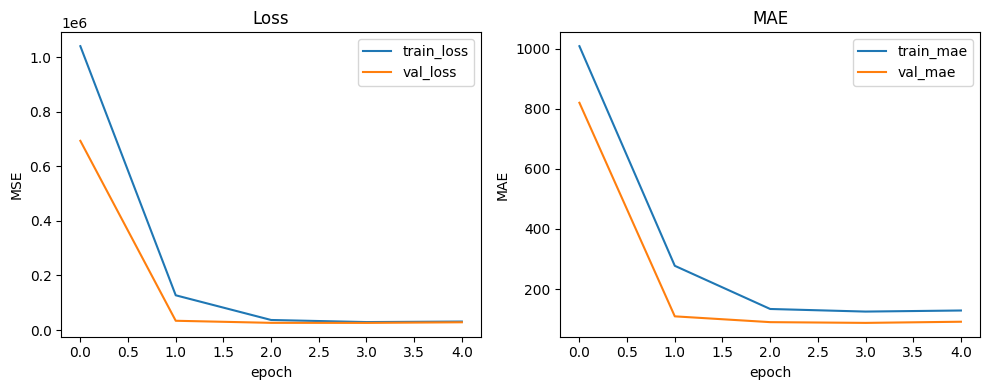

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step


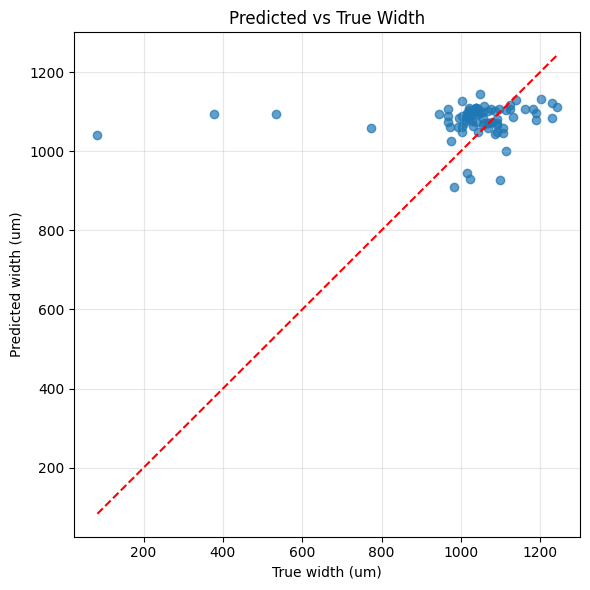

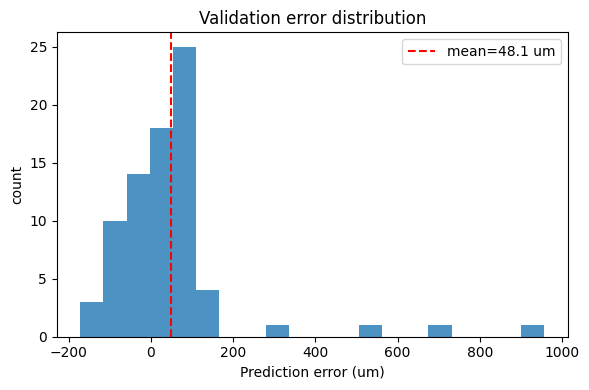

Validation MAE = 91.08 um
Validation RMSE = 168.70 um


In [15]:
# Step 4: visualize training history and validation predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="train_mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.title("MAE")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.show()

predictions = model.predict({"sem_input": X_sem_val, "thermal_input": X_th_val})
true_values = y_val
error = predictions[:,0] - true_values

plt.figure(figsize=(6,6))
plt.scatter(true_values, predictions[:,0], alpha=0.7)
plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], color="red", linestyle="--")
plt.xlabel("True width (um)")
plt.ylabel("Predicted width (um)")
plt.title("Predicted vs True Width")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(error, bins=20, color="tab:blue", alpha=0.8)
plt.axvline(error.mean(), color="red", linestyle="--", label=f"mean={error.mean():.1f} um")
plt.xlabel("Prediction error (um)")
plt.ylabel("count")
plt.title("Validation error distribution")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation MAE = {np.mean(np.abs(error)):.2f} um")
print(f"Validation RMSE = {np.sqrt(np.mean(error**2)):.2f} um")


## Width labels over the whole grid

`build_labels()` sweeps every frame-centre x for all tracks and returns `width_mm` + a `quality`
flag (False where x is outside a track's height coverage or an edge is clipped). 

In [16]:
# Step 5: display a comparison table for validation samples and error correlations
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = model.predict({"sem_input": X_sem_val, "thermal_input": X_th_val})[:, 0]
true_values = y_val
sample_ids = aligned_sample_ids[val_idx]

mae = mean_absolute_error(true_values, predictions)
rmse = np.sqrt(mean_squared_error(true_values, predictions))
r2 = r2_score(true_values, predictions)
print(f"Validation MAE = {mae:.2f} um")
print(f"Validation RMSE = {rmse:.2f} um")
print(f"Validation R^2 = {r2:.4f}")

thermal_mean = X_th_val.reshape(X_th_val.shape[0], -1).mean(axis=1)
thermal_std = X_th_val.reshape(X_th_val.shape[0], -1).std(axis=1)

comparison_df = pd.DataFrame({
    "sample_id": sample_ids,
    "aligned_x_mm": aligned_x_mm[val_idx],
    "SEM_val_sample_shape": [x.shape for x in X_sem_val],
    "thermal_val_sample_shape": [x.shape for x in X_th_val],
    "thermal_mean": thermal_mean,
    "thermal_std": thermal_std,
    "predicted_width_um": predictions,
    "true_width_um": true_values,
    "error_um": predictions - true_values,
})
comparison_df["abs_error_um"] = comparison_df["error_um"].abs()
comparison_df = comparison_df.sort_values("abs_error_um", ascending=False)

print("Top 10 validation samples by absolute error:")
print(comparison_df.head(10)[["sample_id", "aligned_x_mm", "predicted_width_um", "true_width_um", "error_um", "abs_error_um"]])

print("Correlation of error with true width:", comparison_df["error_um"].corr(comparison_df["true_width_um"]))
print("Correlation of error with thermal mean:", comparison_df["error_um"].corr(comparison_df["thermal_mean"]))
print("Correlation of error with thermal std:", comparison_df["error_um"].corr(comparison_df["thermal_std"]))

comparison_df.head(20)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 339ms/step
Validation MAE = 91.08 um
Validation RMSE = 168.70 um
Validation R^2 = -0.0950
Top 10 validation samples by absolute error:
     sample_id  aligned_x_mm  predicted_width_um  true_width_um    error_um  \
54  T08_X098.7          98.7         1040.882935      83.622002  957.260925   
72  T08_X022.3          22.3         1093.508911     378.290009  715.218872   
26  T08_X022.5          22.5         1094.953979     533.588013  561.365967   
34  T08_X098.5          98.5         1057.442505     772.507996  284.934509   
7   T08_X051.3          51.3          926.613647    1099.031982 -172.418335   
14  T08_X090.1          90.1         1094.988159     943.734009  151.254150   
62  T08_X084.3          84.3         1084.372681    1230.437988 -146.065308   
59  T08_X071.9          71.9         1106.686157     967.625977  139.060181   
3   T08_X052.7          52.7         1112.158569    1242.384033 -130.225464   
75  T08_X032.3          32.3         1126.39392

,sample_id,aligned_x_mm,SEM_val_sample_shape,thermal_val_sample_shape,thermal_mean,thermal_std,predicted_width_um,true_width_um,error_um,abs_error_um
54,T08_X098.7,98.7,"(768, 34, 2)","(400, 400, 5)",0.412530,0.058205,1040.882935,83.622002,957.260925,957.260925
72,T08_X022.3,22.3,"(768, 34, 2)","(400, 400, 5)",0.413707,0.057062,1093.508911,378.290009,715.218872,715.218872
26,T08_X022.5,22.5,"(768, 34, 2)","(400, 400, 5)",0.414252,0.057250,1094.953979,533.588013,561.365967,561.365967
34,T08_X098.5,98.5,"(768, 34, 2)","(400, 400, 5)",0.413776,0.057616,1057.442505,772.507996,284.934509,284.934509
7,T08_X051.3,51.3,"(768, 34, 2)","(400, 400, 5)",0.410149,0.057172,926.613647,1099.031982,-172.418335,172.418335
14,T08_X090.1,90.1,"(768, 34, 2)","(400, 400, 5)",0.411382,0.057025,1094.988159,943.734009,151.254150,151.254150
62,T08_X084.3,84.3,"(768, 34, 2)","(400, 400, 5)",0.416589,0.056892,1084.372681,1230.437988,-146.065308,146.065308
59,T08_X071.9,71.9,"(768, 34, 2)","(400, 400, 5)",0.414223,0.057942,1106.686157,967.625977,139.060181,139.060181
3,T08_X052.7,52.7,"(768, 34, 2)","(400, 400, 5)",0.415340,0.056853,1112.158569,1242.384033,-130.225464,130.225464
75,T08_X032.3,32.3,"(768, 34, 2)","(400, 400, 5)",0.412276,0.056625,1126.393921,1003.463989,122.929932,122.929932


In [17]:
# Step 6: evaluate on an unseen SEM track for generalization
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

holdout_track = 10
holdout_path = PROJECT_DIR / "Samples" / "SEM Samples" / f"SEM_samples_Track_{holdout_track:02d}.npz"
holdout_data = np.load(holdout_path, allow_pickle=True)
print("Loaded holdout SEM file:", holdout_path)

track_mask = (labels["track_id"] == holdout_track) & labels["quality"]
label_sample_ids = np.array([
    f"T{int(track):02d}_X{float(x):05.1f}"
    for track, x in zip(labels["track_id"], labels["x_mm"])
])
holdout_label_ids = label_sample_ids[track_mask]
aligned_holdout_ids = np.intersect1d(holdout_data["sample_ids"], holdout_label_ids)
print("Holdout aligned sample count:", aligned_holdout_ids.size)

sem_index = {sid: idx for idx, sid in enumerate(holdout_data["sample_ids"])}
label_index = {sid: idx for idx, sid in enumerate(label_sample_ids)}
aligned_sem_indices = np.array([sem_index[sid] for sid in aligned_holdout_ids], dtype=int)
aligned_label_indices = np.array([label_index[sid] for sid in aligned_holdout_ids], dtype=int)

holdout_sem_images = holdout_data["deposit_only_slices"][aligned_sem_indices]
holdout_sem_masks = holdout_data["deposit_masks"][aligned_sem_indices]
holdout_x_mm = holdout_data["x_mm"][aligned_sem_indices]
holdout_width_um = (labels["width_mm"] * 1000)[aligned_label_indices]

holdout_sem_input = np.stack([holdout_sem_images.astype(np.float32) / 255.0, holdout_sem_masks.astype(np.float32)], axis=-1)
holdout_thermal = np.transpose(np.stack([gen.thermal_tensor(holdout_track, float(x), k=2) for x in holdout_x_mm], axis=0).astype(np.float32), (0, 2, 3, 1)) / thermal_scale

print("Holdout SEM input shape:", holdout_sem_input.shape)
print("Holdout thermal input shape:", holdout_thermal.shape)
print("Holdout target shape:", holdout_width_um.shape)

holdout_predictions = model.predict({"sem_input": holdout_sem_input, "thermal_input": holdout_thermal})[:, 0]
holdout_mae = mean_absolute_error(holdout_width_um, holdout_predictions)
holdout_rmse = np.sqrt(mean_squared_error(holdout_width_um, holdout_predictions))
holdout_r2 = r2_score(holdout_width_um, holdout_predictions)
print(f"Holdout MAE = {holdout_mae:.2f} um")
print(f"Holdout RMSE = {holdout_rmse:.2f} um")
print(f"Holdout R^2 = {holdout_r2:.4f}")

holdout_df = pd.DataFrame({
    "sample_id": aligned_holdout_ids,
    "aligned_x_mm": holdout_x_mm,
    "predicted_width_um": holdout_predictions,
    "true_width_um": holdout_width_um,
    "error_um": holdout_predictions - holdout_width_um,
})
holdout_df["abs_error_um"] = holdout_df["error_um"].abs()
holdout_df = holdout_df.sort_values("abs_error_um", ascending=False)
print("Top 10 holdout errors:", holdout_df.head(10)[["sample_id", "aligned_x_mm", "predicted_width_um", "true_width_um", "error_um", "abs_error_um"]])

holdout_df["width_bin"] = pd.cut(holdout_df["true_width_um"], bins=5)
print("Mean absolute error by true width range:")
print(holdout_df.groupby("width_bin")["abs_error_um"].mean())


Loaded holdout SEM file: /Users/qalbemomina/Documents/NSF-Challenge/nsf-fmrg-data-challenge/Samples/SEM Samples/SEM_samples_Track_10.npz
Holdout aligned sample count: 369
Holdout SEM input shape: (369, 768, 34, 2)
Holdout thermal input shape: (369, 400, 400, 5)
Holdout target shape: (369,)
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step
Holdout MAE = 239.34 um
Holdout RMSE = 305.98 um
Holdout R^2 = -1.8554
Top 10 holdout errors:       sample_id  aligned_x_mm  predicted_width_um  true_width_um    error_um  \
362  T10_X098.5          98.5         1035.504517         39.820  995.684517   
365  T10_X099.1          99.1         1032.788818         39.820  992.968818   
0    T10_X023.9          23.9         1047.422241         55.748  991.674241   
367  T10_X099.5          99.5         1026.560181         39.820  986.740181   
364  T10_X098.9          98.9         1034.084961         47.784  986.300961   
5    T10_X026.7          26.7         1045.195801         63.712  981.483801   
366  T10_X099.

/var/folders/t3/m3vvzkvx1_v8glpdp_v18n000000gn/T/ipykernel_3896/1008449567.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(holdout_df.groupby("width_bin")["abs_error_um"].mean())
